# Access Sentinel-1 in Native Mode

**xarray-eopf** is a Python package that extends **xarray** with a custom backend called `"eopf-zarr"`. This backend enables **seamless access to ESA EOPF data products** stored in the **Zarr** format, presenting them as analysis-ready data structures.

In this notebook, we demonstrate how to use the **xarray-eopf** backend to access **Sentinel-1** EOPF Zarr products in **native mode**. All data access is *lazy*, meaning that data is only loaded when required—for example, during plotting or when writing to storage. 

For a general introduction to the xarray EOPF backend, see the [introduction notebook](./introduction.ipynb).

- 🐙 **GitHub:** [EOPF Sample Service – xarray-eopf](https://github.com/EOPF-Sample-Service/xarray-eopf)  
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xarray-eopf/issues)  
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xarray-eopf/)

---

## Import Modules

The `xarray-eopf` backend is implemented as a plugin for `xarray`. Once installed, it registers automatically and requires no additional import. You can simply import `xarray` as usual:

In [1]:
import matplotlib.pyplot as plt
import pystac_client
import xarray as xr

---

## Open a Sentinel-1 GRD 

We begin with an example that accesses a Sentinel-1 GRD product in **native mode**. 

---

## Find a Sentinel-1 GRD Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l1-grd) to search for a Sentinel-1 GRD tile.

In [2]:
%%time
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-1-l1-grd"],
        bbox=[16, 40, 17, 41],
        datetime=["2026-03-16", "2026-03-16"],
    ).items()
)
items

CPU times: user 22.5 ms, sys: 3.07 ms, total: 25.6 ms
Wall time: 4.1 s


[<Item id=S1C_IW_GRDH_1SDV_20260316T164819_20260316T164844_006792_00DBA6_AE14>,
 <Item id=S1C_IW_GRDH_1SDV_20260316T164754_20260316T164819_006792_00DBA6_8EA0>,
 <Item id=S1A_IW_GRDH_1SDV_20260316T045550_20260316T045615_063648_080022_7C56>]

Next, we can inspect the item’s contents, including the additional field `xarray:open_datatree_kwargs`, which provides the arguments needed to open the product using Xarray’s `eopf-zarr` engine.

In [3]:
item = items[1]
item

<Item id=S1C_IW_GRDH_1SDV_20260316T164754_20260316T164819_006792_00DBA6_8EA0>

## Open Sentinel-1 GRD in native mode as `xarray.DataTree`

We can use the `"product"` asset to obtain the `href` and `xarray:open_datatree_kwargs` from the STAC item, and open the product as an `xarray.DataTree` as shown below:

In [4]:
%%time
dt = xr.open_datatree(
    item.assets["product"].href,
    **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"]
)
dt

CPU times: user 718 ms, sys: 110 ms, total: 828 ms
Wall time: 5.17 s


<xarray.DataTree>
Group: /
│   Attributes: (2)
├── Group: /S01SIWGRD_20260316T164754_0025_C039_8EA0_00DBA6_VH
│   │   Attributes: (3)
│   ├── Group: /S01SIWGRD_20260316T164754_0025_C039_8EA0_00DBA6_VH/conditions
│   │   ├── Group: /S01SIWGRD_20260316T164754_0025_C039_8EA0_00DBA6_VH/conditions/antenna_pattern
│   │   │       Dimensions:              (azimuth_time: 27, count: 730)
│   │   │       Coordinates:
│   │   │         * azimuth_time         (azimuth_time) datetime64[ns] 216B 2026-03-16T16:47:...
│   │   │         * count                (count) int64 6kB 0 1 2 3 4 5 ... 725 726 727 728 729
│   │   │       Data variables:
│   │   │           elevation_angle      (azimuth_time, count) float32 79kB dask.array<chunksize=(27, 730), meta=np.ndarray>
│   │   │           incidence_angle      (azimuth_time, count) float32 79kB dask.array<chunksize=(27, 730), meta=np.ndarray>
│   │   │           roll                 (azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           slant_range_time_ap  (azimuth_time, count) float64 158kB dask.array<chunksize=(27, 730), meta=np.ndarray>
│   │   │           swath                (azimuth_time) <U3 324B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           terrain_height       (azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   ├── Group: /S01SIWGRD_20260316T164754_0025_C039_8EA0_00DBA6_VH/conditions/attitude
│   │   │       Dimensions:       (azimuth_time: 25)
│   │   │       Coordinates:
│   │   │         * azimuth_time  (azimuth_time) datetime64[ns] 200B 2026-03-16T16:47:55.0000...
│   │   │       Data variables:
│   │   │           pitch         (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q0            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q1            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q2            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           q3            (azimuth_time) float32 100B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           roll          (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           wx            (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           wy            (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           wz            (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   │           yaw           (azimuth_time) float64 200B dask.array<chunksize=(25,), meta=np.ndarray>
│   │   ├── Group: /S01SIWGRD_20260316T164754_0025_C039_8EA0_00DBA6_VH/conditions/doppler_centroid
│   │   │       Dimensions:                            (azimuth_time: 27, degree: 3)
│   │   │       Coordinates:
│   │   │         * azimuth_time                       (azimuth_time) datetime64[ns] 216B 202...
│   │   │         * degree                             (degree) int64 24B 2 1 0
│   │   │       Data variables:
│   │   │           data_dc_polynomial                 (azimuth_time, degree) float32 324B dask.array<chunksize=(27, 3), meta=np.ndarray>
│   │   │           data_dc_rms_error                  (azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           data_dc_rms_error_above_threshold  (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           fine_dce_azimuth_start_time        (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           fine_dce_azimuth_stop_time         (azimuth_time) bool 27B dask.array<chunksize=(27,), meta=np.ndarray>
│   │   │           geometry_dc_polynomial             (azimuth_time, degree) float32 324B dask.array<chunksize=(27, 3), meta=np.ndarray>
│   │   │           t0                                 (azimuth_time) float64 216

We can extract the `"VV"` band as shown below: 

In [5]:
ds = dt.S01SIWGRD_20260316T164754_0025_C039_8EA0_00DBA6_VH.measurements.to_dataset()
ds

<xarray.Dataset> Size: 890MB
Dimensions:       (azimuth_time: 16689, ground_range: 26642)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2026-03-16T16:47:54.761...
  * ground_range  (ground_range) float64 213kB 0.0 10.0 ... 2.664e+05 2.664e+05
    line          (azimuth_time) int64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
    pixel         (ground_range) int64 213kB dask.array<chunksize=(4096,), meta=np.ndarray>
Data variables:
    grd           (azimuth_time, ground_range) uint16 889MB dask.array<chunksize=(2048, 4096), meta=np.ndarray>

As an example, we plot the raw GRD array. 

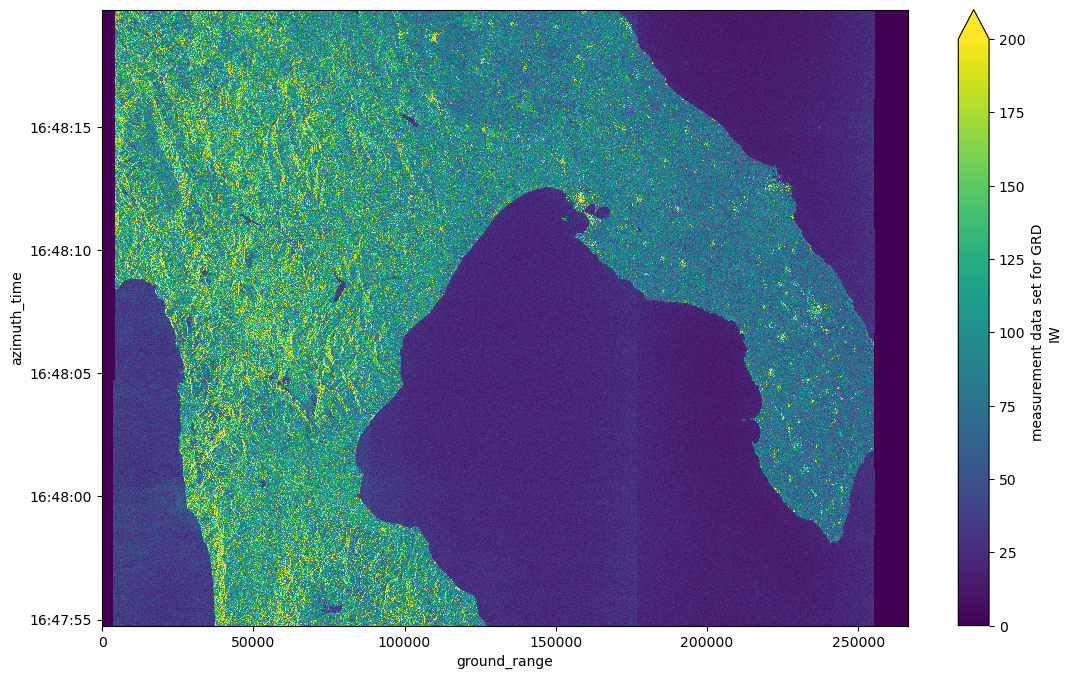

In [6]:
ds.grd[::10, ::10].plot(vmax=200, figsize=(13, 8))

### Open Sentinel-1 GRD VH group in native mode as `xarray.Dataset`

Similarily, we can open the individual polarisation bands (assets `"vh"` and `"vv"`) to open the individual groups as an `xarray.Dataset` as shown below:

In [7]:
%%time
ds = xr.open_dataset(
    item.assets["vh"].href,
    **item.assets["vh"].extra_fields["xarray:open_dataset_kwargs"]
)
ds

CPU times: user 22.3 ms, sys: 3.92 ms, total: 26.2 ms
Wall time: 350 ms


<xarray.Dataset> Size: 890MB
Dimensions:       (azimuth_time: 16689, ground_range: 26642)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2026-03-16T16:47:54.761...
  * ground_range  (ground_range) float64 213kB 0.0 10.0 ... 2.664e+05 2.664e+05
    line          (azimuth_time) int64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
    pixel         (ground_range) int64 213kB dask.array<chunksize=(4096,), meta=np.ndarray>
Data variables:
    grd           (azimuth_time, ground_range) uint16 889MB dask.array<chunksize=(2048, 4096), meta=np.ndarray>

### Open Sentinel-1 GRD as `xarray.Dataset`

The `xarray.DataTree` model was introduced in xarray v2024.10.0 (October 2024). To maintain compatibility with workflows based on `xr.Dataset`, the function `xarray.open_dataset(..., engine="eopf-zarr", op_mode="native")` is provided, which flattens the `DataTree` into a single dataset.

During this process, hierarchical groups in the Zarr product are merged, and variable as well as dimension names are prefixed with their group paths (using `_` by default) to ensure uniqueness. For example, `S01SIWGRD_20260316T045550_0025_A364_7C56_080022_VH.measurements` becomes `S01SIWGRD_20260316T045550_0025_A364_7C56_080022_VH_measurements`.

In [8]:
%%time
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    op_mode="native",
    chunks={},
)
ds

CPU times: user 219 ms, sys: 10.8 ms, total: 230 ms
Wall time: 2.26 s


<xarray.Dataset> Size: 2GB
Dimensions:                                                           (
                                                                       VH_conditions_antenna_pattern_azimuth_time: 27,
                                                                       VH_conditions_antenna_pattern_count: 730,
                                                                       VH_conditions_attitude_azimuth_time: 25,
                                                                       VH_conditions_doppler_centroid_azimuth_time: 27,
                                                                       VH_conditions_doppler_centroid_degree: 3,
                                                                       ...
                                                                       VV_quality_calibration_azimuth_time: 27,
                                                                       VV_quality_calibration_ground_range: 668,
                                                                       VV_quality_azimuth_swath: 3,
                                                                       VV_quality_azimuth_azimuth_time: 1688,
                                                                       VV_quality_range_azimuth_time: 26,
                                                                       VV_quality_range_ground_range: 671)
Coordinates: (12/58)
  * VH_conditions_antenna_pattern_azimuth_time                        (VH_conditions_antenna_pattern_azimuth_time) datetime64[ns] 216B ...
  * VH_conditions_antenna_pattern_count                               (VH_conditions_antenna_pattern_count) int64 6kB ...
  * VH_conditions_attitude_azimuth_time                               (VH_conditions_attitude_azimuth_time) datetime64[ns] 200B ...
  * VH_conditions_doppler_centroid_azimuth_time                       (VH_conditions_doppler_centroid_azimuth_time) datetime64[ns] 216B ...
  * VH_conditions_doppler_centroid_degree                             (VH_conditions_doppler_centroid_degree) int64 24B ...
  * VH_conditions_gcp_azimuth_time                                    (VH_conditions_gcp_azimuth_time) datetime64[ns] 80B ...
    ...                                                                ...
    VV_quality_azimuth_line                                           (VV_quality_azimuth_swath, VV_quality_azimuth_azimuth_time) int32 20kB dask.array<chunksize=(3, 1688), meta=np.ndarray>
  * VV_quality_azimuth_swath                                          (VV_quality_azimuth_swath) <U3 36B ...
    VV_quality_range_ground_range                                     (VV_quality_range_azimuth_time, VV_quality_range_ground_range) float64 140kB dask.array<chunksize=(26, 671), meta=np.ndarray>
  * VV_quality_range_azimuth_time                                     (VV_quality_range_azimuth_time) datetime64[ns] 208B ...
    VV_quality_range_line                                             (VV_quality_range_azimuth_time) int32 104B dask.array<chunksize=(26,), meta=np.ndarray>
    VV_quality_range_pixel                                            (VV_quality_range_azimuth_time, VV_quality_range_ground_range) int32 70kB dask.array<chunksize=(26, 671), meta=np.ndarray>
Dimensions without coordinates: VH_quality_azimuth_azimuth_time,
                                VV_quality_azimuth_azimuth_time
Data variables: (12/78)
    VH_conditions_antenna_pattern_elevation_angle                     (VH_conditions_antenna_pattern_azimuth_time, VH_conditions_antenna_pattern_count) float32 79kB dask.array<chunksize=(27, 730), meta=np.ndarray>
    VH_conditions_antenna_pattern_incidence_angle                     (VH_conditions_antenna_pattern_azimuth_time, VH_conditions_antenna_pattern_count) float32 79kB dask.array<chunksize=(27, 730), meta=np.ndarray>
    VH_conditions_antenna_pattern_roll                                (VH_conditions_antenna_pattern_azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarr

The separator character used in flattened variable names can be customized via the `group_sep` parameter. Additionally, you can filter the returned variables using the `variables` keyword argument, which accepts a string, an iterable of names, or a regular expression (regex) pattern.

In this example, we use a regex to select all arrays associated with the VH band.

In [9]:
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    op_mode="native",
    chunks={},
    group_sep="/",
    variables="^VH.*",
)
ds

<xarray.Dataset> Size: 890MB
Dimensions:                                                           (
                                                                       VH/conditions/antenna_pattern/azimuth_time: 27,
                                                                       VH/conditions/antenna_pattern/count: 730,
                                                                       VH/conditions/attitude/azimuth_time: 25,
                                                                       VH/conditions/doppler_centroid/azimuth_time: 27,
                                                                       VH/conditions/doppler_centroid/degree: 3,
                                                                       ...
                                                                       VH/quality/calibration/azimuth_time: 27,
                                                                       VH/quality/calibration/ground_range: 668,
                                                                       VH/quality/azimuth/swath: 3,
                                                                       VH/quality/azimuth/azimuth_time: 1688,
                                                                       VH/quality/range/azimuth_time: 26,
                                                                       VH/quality/range/ground_range: 671)
Coordinates: (12/16)
  * VH/conditions/antenna_pattern/azimuth_time                        (VH/conditions/antenna_pattern/azimuth_time) datetime64[ns] 216B ...
  * VH/conditions/antenna_pattern/count                               (VH/conditions/antenna_pattern/count) int64 6kB ...
  * VH/conditions/attitude/azimuth_time                               (VH/conditions/attitude/azimuth_time) datetime64[ns] 200B ...
  * VH/conditions/doppler_centroid/azimuth_time                       (VH/conditions/doppler_centroid/azimuth_time) datetime64[ns] 216B ...
  * VH/conditions/doppler_centroid/degree                             (VH/conditions/doppler_centroid/degree) int64 24B ...
  * VH/conditions/gcp/azimuth_time                                    (VH/conditions/gcp/azimuth_time) datetime64[ns] 80B ...
    ...                                                                ...
  * VH/measurements/ground_range                                      (VH/measurements/ground_range) float64 213kB ...
  * VH/quality/calibration/azimuth_time                               (VH/quality/calibration/azimuth_time) datetime64[ns] 216B ...
  * VH/quality/calibration/ground_range                               (VH/quality/calibration/ground_range) float64 5kB ...
  * VH/quality/azimuth/swath                                          (VH/quality/azimuth/swath) <U3 36B ...
    VH/quality/range/ground_range                                     (VH/quality/range/azimuth_time, VH/quality/range/ground_range) float64 140kB dask.array<chunksize=(26, 671), meta=np.ndarray>
  * VH/quality/range/azimuth_time                                     (VH/quality/range/azimuth_time) datetime64[ns] 208B ...
Dimensions without coordinates: VH/quality/azimuth/azimuth_time
Data variables: (12/39)
    VH/conditions/antenna_pattern/elevation_angle                     (VH/conditions/antenna_pattern/azimuth_time, VH/conditions/antenna_pattern/count) float32 79kB dask.array<chunksize=(27, 730), meta=np.ndarray>
    VH/conditions/antenna_pattern/incidence_angle                     (VH/conditions/antenna_pattern/azimuth_time, VH/conditions/antenna_pattern/count) float32 79kB dask.array<chunksize=(27, 730), meta=np.ndarray>
    VH/conditions/antenna_pattern/roll                                (VH/conditions/antenna_pattern/azimuth_time) float64 216B dask.array<chunksize=(27,), meta=np.ndarray>
    VH/conditions/antenna_pattern/slant_range_time_ap                 (VH/conditions/antenna_pattern/azimuth_time, VH/conditions/antenna_pattern/count) float64 158kB dask.array<chunksize=(27, 730), meta=np.ndarray>
    VH/con

We can now plot the GRD array and the coarse 2d latitude and longitude grids, which can be used for geolocation.

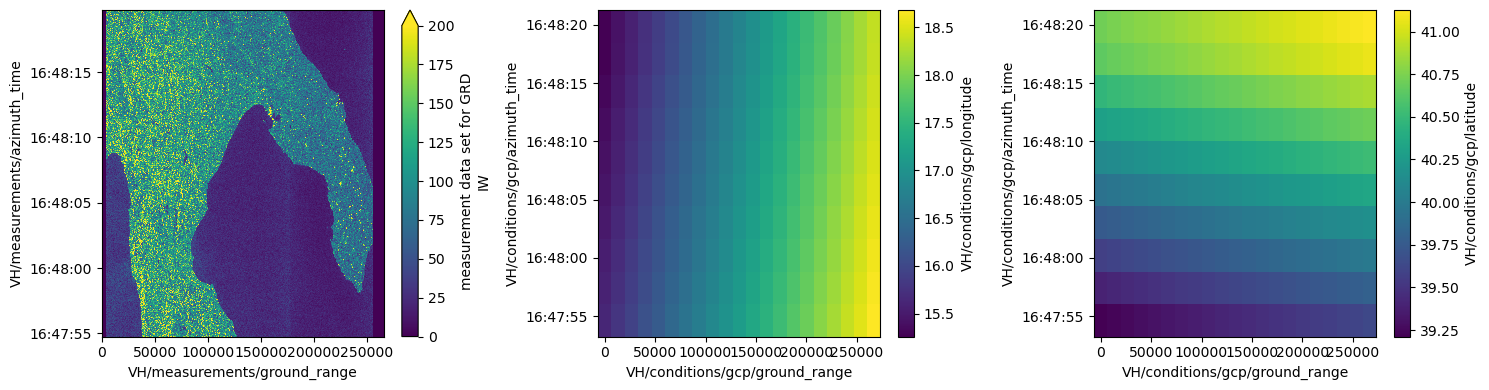

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ds["VH/measurements/grd"][::10, ::10].plot.imshow(ax=ax[0], vmax=200)
ds["VH/conditions/gcp/longitude"].plot.imshow(ax=ax[1])
ds["VH/conditions/gcp/latitude"].plot.imshow(ax=ax[2])
plt.tight_layout()

---

## Open a Sentinel-1 Level-2 OCN

We now access a Sentinel-1 Level-2 OCN product in **native mode**. The data access methods shown above apply equally to Sentinel-1 Level-2 OCN products.

### Find a Sentinel-1 Level-2 OCN Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l2-ocn) to search for available Sentinel-1 Level-2 OCN tiles.

In [11]:
%%time
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-1-l2-ocn"],
        bbox=[16, 40, 17, 41],
        datetime=["2025-07-30", "2025-07-31"],
    ).items()
)
items

CPU times: user 14.8 ms, sys: 1.1 ms, total: 15.9 ms
Wall time: 210 ms


[<Item id=S1C_IW_OCN__2SDV_20250730T050308_20250730T050333_003445_006EB7_446E>,
 <Item id=S1C_IW_OCN__2SDV_20250730T050243_20250730T050308_003445_006EB7_7BAE>]

In [12]:
item = items[0]
item

<Item id=S1C_IW_OCN__2SDV_20250730T050308_20250730T050333_003445_006EB7_446E>

### Open Sentinel-1 Level-2 OCN as `xarray.DataTree`

We can use the `"product"` asset to obtain the `href` and `xarray:open_datatree_kwargs` from the STAC item, and open the product as an `xarray.DataTree` as shown below:

In [13]:
%%time
dt = xr.open_datatree(
    item.assets["product"].href,
    **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"]
)
dt

CPU times: user 89.9 ms, sys: 2.47 ms, total: 92.4 ms
Wall time: 261 ms


<xarray.DataTree>
Group: /
│   Attributes: (2)
├── Group: /osw
│   │   Attributes: (2)
│   └── Group: /osw/S01SIWOCN_20250730T050308_0025_C020_446E_006EB7_VV
│       │   Attributes: (2)
│       ├── Group: /osw/S01SIWOCN_20250730T050308_0025_C020_446E_006EB7_VV/conditions
│       │       Dimensions:                                 (azimuth: 1, range: 1,
│       │                                                    partition: 1, lag: 1, ky: 1,
│       │                                                    kx: 1, angular_binsize: 1,
│       │                                                    wavenumber_binsize: 1)
│       │       Coordinates:
│       │           jx                                      (kx) float32 4B dask.array<chunksize=(1,), meta=np.ndarray>
│       │           jy                                      (ky) float32 4B dask.array<chunksize=(1,), meta=np.ndarray>
│       │           k                                       (wavenumber_binsize) float32 4B dask.array<chunksize=(1,), meta=np.ndarray>
│       │         * kx                                      (kx) float32 4B nan
│       │         * ky                                      (ky) float32 4B nan
│       │           latitude                                (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           longitude                               (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           phi                                     (angular_binsize) float32 4B dask.array<chunksize=(1,), meta=np.ndarray>
│       │       Dimensions without coordinates: azimuth, range, partition, lag,
│       │                                       angular_binsize, wavenumber_binsize
│       │       Data variables: (12/31)
│       │           ambiguity_factor                        (azimuth, range, partition) float32 4B dask.array<chunksize=(1, 1, 1), meta=np.ndarray>
│       │           auxiliary_wind_direction                (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           auxiliary_wind_speed                    (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           azimuth_cutoff                          (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           azimuth_size                            (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           azimuth_size_slc                        (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           ...                                      ...
│       │           range_cutoff                            (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           range_size_slc                          (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           skewness                                (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           spectrum_resolution                     (azimuth, range, angular_binsize) float32 4B dask.array<chunksize=(1, 1, 1), meta=np.ndarray>
│       │           wind_direction                          (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       │           wind_speed                              (azimuth, range) float32 4B dask.array<chunksize=(1, 1), meta=np.ndarray>
│       ├── Group: /osw/S01SIWOCN_20250730T050308_0025_C020_446E_006EB7_VV/measurements
│       │       Dimensions:                      (azimuth: 1, range: 1, partition: 1,
│       │                                         angular_binsize: 1, wavenumber_binsize: 1)
│       │       Coordinates:
│       │           k                            (wavenumber_binsize) float32 4B dask.array<chunksize=(1,), meta=np.ndarray>
│       │           latitude                     (azimuth, range) float32 4B dask.arr

We can extract the ocean wind field dataset as shown below:

In [14]:
ds = dt.owi.S01SIWOCN_20250730T050308_0025_C020_446E_006EB7_VV.measurements.to_dataset()
ds

<xarray.Dataset> Size: 704kB
Dimensions:         (azimuth: 166, range: 265)
Coordinates:
    latitude        (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>
    longitude       (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>
Dimensions without coordinates: azimuth, range
Data variables:
    wind_direction  (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>
    wind_speed      (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>

As an example, we plot the two ocean wind field array. 

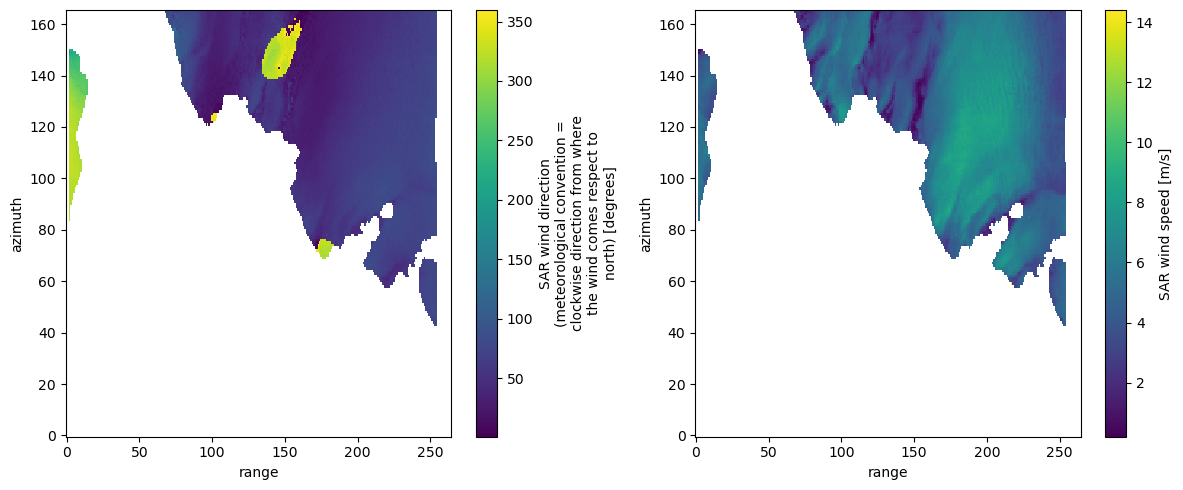

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ds.wind_direction.plot(ax=ax[0])
ds.wind_speed.plot(ax=ax[1])
plt.tight_layout()

### Open Sentinel-1 Level-2 OCN OWI Group as `xarray.Dataset`

We can access the individual sub-groups directly by using the assets `"osw"`, `"owi"`, and `"rvl"`. The opening parameters are stored in the asset’s extra field `"xarray:open_dataset_kwargs"`.

In [16]:
ds = xr.open_dataset(
    item.assets["owi"].href,
    **item.assets["owi"].extra_fields["xarray:open_dataset_kwargs"],
)
ds

<xarray.Dataset> Size: 704kB
Dimensions:         (azimuth: 166, range: 265)
Coordinates:
    latitude        (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>
    longitude       (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>
Dimensions without coordinates: azimuth, range
Data variables:
    wind_direction  (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>
    wind_speed      (azimuth, range) float32 176kB dask.array<chunksize=(166, 265), meta=np.ndarray>

---

### Native resolution of each Sentinel-2 spectral band 

* 10m: [b02, b03, b04, b08]
* 20m: [b05, b06, b07, b8a, b11, b12]
* 60m: [b01, b09, b10]

### Analysis mode for Sentinel-2

The analysis mode for Sentinel-2 has the following key properties:

- **Default mode** when using the `"eopf-zarr"` backend.
- **Spatial resolution options:** Users can choose between 10m, 20m, and 60m, with 10m as the default.
- **Upsampling:**  
  - Performed via 2D interpolation controlled by the `spline_orders` argument.  
  - Accepts a single spline order for all variables or a dictionary mapping spline orders to variable names or data types.  
  - Supported spline orders: 0 (nearest neighbor, default for `scl`), 1 (linear), 2 (bi-linear), 3 (cubic, default).
- **Downsampling:**  
  - Done through aggregation methods governed by the `agg_methods` argument.  
  - Can be a single method for all variables or a dictionary mapping methods to variable names or data types.  
  - Available methods include `"center"` (default for `scl`), `"count"`, `"first"`, `"last"`, `"max"`, `"mean"` (default), `"median"`, `"mode"`, `"min"`, `"prod"`, `"std"`, `"sum"`, and `"var"`. 
- **Variable selection:** Specific variables can be selected via the `variables` argument, which accepts a variable name, a regex pattern, or an iterable of either.

More details are available in the [documentation](https://eopf-sample-service.github.io/xarray-eopf/api/#xarray_eopf.backend.EopfBackend.open_dataset).

Note: Default up- and downsampling methods follow ESA's Sentinel-2 Level 2A guidelines ([documentation PDF](https://step.esa.int/thirdparties/sen2cor/2.10.0/docs/S2-PDGS-MPC-L2A-ATBD-V2.10.0.pdf)).


In [17]:
path = (
    "https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:notebook-data/tutorial_data/"
    "cpm_v262/S2A_MSIL2A_20200707T101031_N0500_R022_T32TPS_20230614T182201.zarr"
)

By default, without specifying any keyword arguments, the function returns an `xr.Dataset` with all spectral bands at 10m spatial resolution.


In [18]:
%%time
ds_default = xr.open_dataset(path, engine="eopf-zarr", chunks={})
ds_default

CPU times: user 296 ms, sys: 10.5 ms, total: 307 ms
Wall time: 2.39 s


<xarray.Dataset> Size: 13GB
Dimensions:      (x: 10980, y: 10980)
Coordinates:
  * x            (x) float32 44kB 6e+05 6e+05 6e+05 ... 7.098e+05 7.098e+05
  * y            (y) float32 44kB 5.2e+06 5.2e+06 5.2e+06 ... 5.09e+06 5.09e+06
    spatial_ref  int64 8B ...
Data variables: (12/15)
    b02          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b03          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b04          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b08          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b01          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b05          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    ...           ...
    b12          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b8a          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    cld          (y, x) float32 482MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    snw          (y, x) float32 482MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    scl          (y, x) uint8 121MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b09          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
Attributes: (24)

Now, we can explore how to configure the processing using the available keyword arguments.

In [19]:
ds_nearest = xr.open_dataset(
    path,
    engine="eopf-zarr",
    chunks={},
    interp_methods="nearest",
    variables=["b01", "b02", "scl"],
)
ds_nearest

<xarray.Dataset> Size: 2GB
Dimensions:      (x: 10980, y: 10980)
Coordinates:
  * x            (x) float32 44kB 6e+05 6e+05 6e+05 ... 7.098e+05 7.098e+05
  * y            (y) float32 44kB 5.2e+06 5.2e+06 5.2e+06 ... 5.09e+06 5.09e+06
    spatial_ref  int64 8B ...
Data variables:
    b02          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b01          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    scl          (y, x) uint8 121MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
Attributes: (24)

We can now compare the different upsampling methods for "b01", which native resolution is at 60m. 

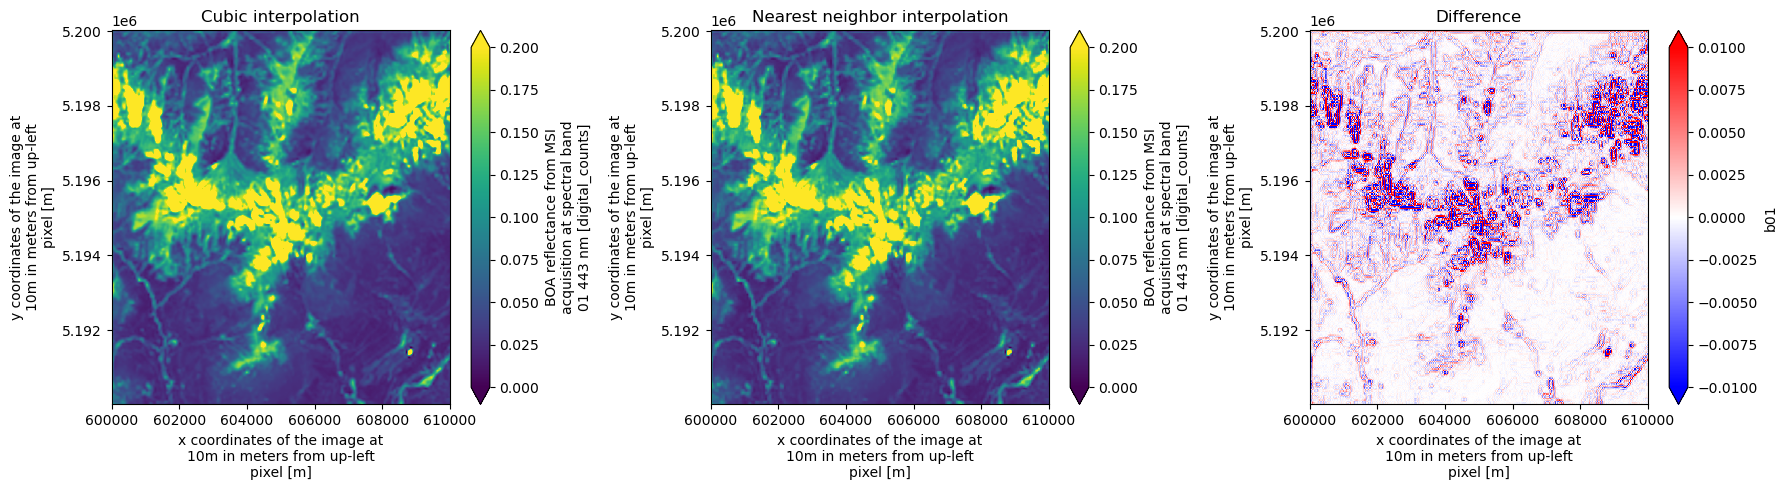

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ds_default.b01[:1000, :1000].plot(ax=ax[0], vmin=0.0, vmax=0.2)
ax[0].set_title("Cubic interpolation")
ds_nearest.b01[:1000, :1000].plot(ax=ax[1], vmin=0.0, vmax=0.2)
ax[1].set_title("Nearest neighbor interpolation")
(ds_default.b01 - ds_nearest.b01)[:1000, :1000].plot(
    ax=ax[2], vmin=-0.01, vmax=0.01, cmap="bwr"
)
ax[2].set_title("Difference")
plt.tight_layout()

### Scene classification layer in Sentinel-2 L2A product

For the SCL, the flag names, values, and corresponding colors are added to the attributes to facilitate plotting. The colors are defined according to [Sentinel Hub’s specifications](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/scene-classification/).

In [21]:
ds = xr.open_dataset(path, engine="eopf-zarr", chunks={}, resolution=60)
ds

<xarray.Dataset> Size: 352MB
Dimensions:      (y: 1830, x: 1830)
Coordinates:
    spatial_ref  int64 8B ...
  * x            (x) float32 7kB 6e+05 6.001e+05 ... 7.097e+05 7.098e+05
  * y            (y) float32 7kB 5.2e+06 5.2e+06 5.2e+06 ... 5.09e+06 5.09e+06
Data variables: (12/15)
    b08          (y, x) float64 27MB dask.array<chunksize=(305, 305), meta=np.ndarray>
    cld          (y, x) float32 13MB dask.array<chunksize=(305, 305), meta=np.ndarray>
    snw          (y, x) float32 13MB dask.array<chunksize=(305, 305), meta=np.ndarray>
    b01          (y, x) float64 27MB dask.array<chunksize=(305, 305), meta=np.ndarray>
    b02          (y, x) float64 27MB dask.array<chunksize=(305, 305), meta=np.ndarray>
    b03          (y, x) float64 27MB dask.array<chunksize=(305, 305), meta=np.ndarray>
    ...           ...
    b07          (y, x) float64 27MB dask.array<chunksize=(305, 305), meta=np.ndarray>
    b09          (y, x) float64 27MB dask.array<chunksize=(305, 305), meta=np.ndarray>
    b11          (y, x) float64 27MB dask.array<chunksize=(305, 305), meta=np.ndarray>
    b12          (y, x) float64 27MB dask.array<chunksize=(305, 305), meta=np.ndarray>
    b8a          (y, x) float64 27MB dask.array<chunksize=(305, 305), meta=np.ndarray>
    scl          (y, x) uint8 3MB dask.array<chunksize=(305, 305), meta=np.ndarray>
Attributes: (24)

NameError: name 'mcolors' is not defined

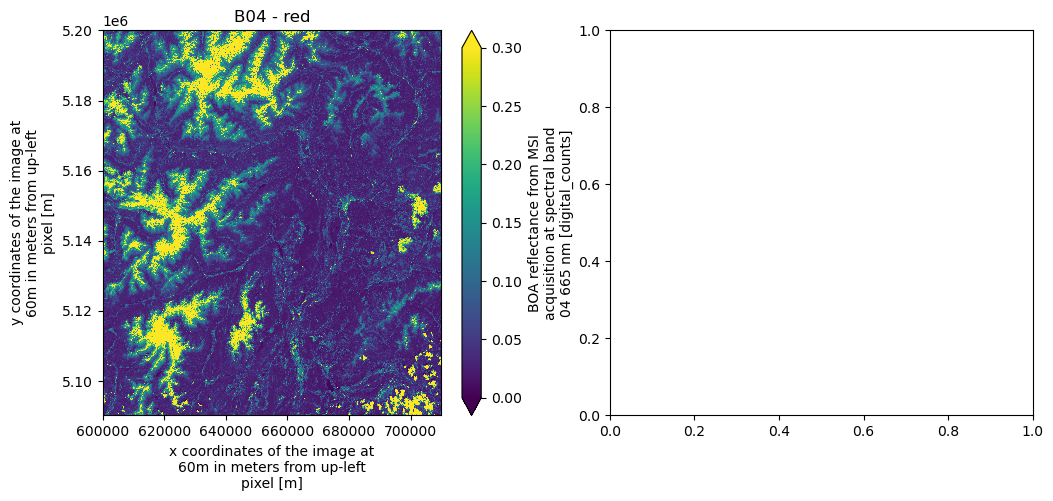

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ds.b04.plot(ax=ax[0], vmin=0.0, vmax=0.3)
ax[0].set_title("B04 - red")

cmap = mcolors.ListedColormap(ds.scl.attrs["flag_colors"].split(" "))
nb_colors = len(ds.scl.attrs["flag_values"])
norm = mcolors.BoundaryNorm(
    boundaries=np.arange(nb_colors + 1) - 0.5, ncolors=nb_colors
)
im = ds.scl.plot.imshow(ax=ax[1], cmap=cmap, norm=norm, add_colorbar=False)
cbar = fig.colorbar(im, ax=ax[1], ticks=ds.scl.attrs["flag_values"])
cbar.ax.set_yticklabels(ds.scl.attrs["flag_meanings"].split(" "))
cbar.set_label("Class")
ax[1].set_title("Scene classification layer")

plt.tight_layout()

### Sentinel-2 L1C

Let’s now open a Sentinel-2 L1C product. In this product, each band is available only at its native resolution. This allows us to demonstrate the aggregation mode used during downsampling.

In [ ]:
path = (
    "https://objectstore.eodc.eu:2222/e05ab01a9d56408d82ac32d69a5aae2a:202504-s02msil1c/30/products"
    "/cpm_v256/S2B_MSIL1C_20250430T101559_N0511_R065_T32TLQ_20250430T124542.zarr"
)

As explained above, the default aggregation method for spectral bands during downsampling is to take the mean of the superpixel.

In [ ]:
ds_agg_mean = xr.open_dataset(path, engine="eopf-zarr", chunks={}, resolution=60)
ds_agg_mean

As a second dataset, we apply `"max"` as aggregation mode. 

In [ ]:
ds_agg_max = xr.open_dataset(
    path, engine="eopf-zarr", chunks={}, resolution=60, agg_methods="max"
)
ds_agg_max

Next, we plot the spectral band B04 (red) alongside the difference between the two aggregation modes.


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ds_agg_max.b04[1000::, 1000::].plot(ax=ax[0], vmin=0.0, vmax=0.2)
ax[0].set_title("Aggregation method 'max'")
ds_agg_mean.b04[1000::, 1000::].plot(ax=ax[1], vmin=0.0, vmax=0.2)
ax[1].set_title("Aggregation method 'mean'")
(ds_agg_max.b04 - ds_agg_mean.b04)[1000::, 1000::].plot(
    ax=ax[2], vmin=-0.05, vmax=0.05, cmap="bwr"
)
ax[2].set_title("Difference")
plt.tight_layout()

---

## Conclusion

This notebook demonstrates how to access Sentinel-1 EOPF Zarr samples in **native mode** using the **xarray-eopf** plugin. Key takeaways are:

- Access Sentinel-1 Level-1 GRD, and Sentinel-1 Level-2 OCN products.  
- Open the full Zarr store as an `xr.DataTree` using `xr.open_datatree` and the asset `"product"`.  
- Open subgroups (e.g., `"osw"`, `"owi"`, and `"rvl"`) as `xr.Dataset` using `xr.open_dataset`.  
- Open the full Zarr store as a flattened `xr.Dataset` using `xr.open_dataset` and the asset `"product"`.  
- Filter variables using the `variables` keyword argument.

> **Note:**  
> This notebook only covers the **native mode**, which presents the data as close as possible to the original product.  
> The **anaylsis mode** will be presented once implemented.  
> Examples for Sentienl-1 SLC will be presented once published through the STAC API.  

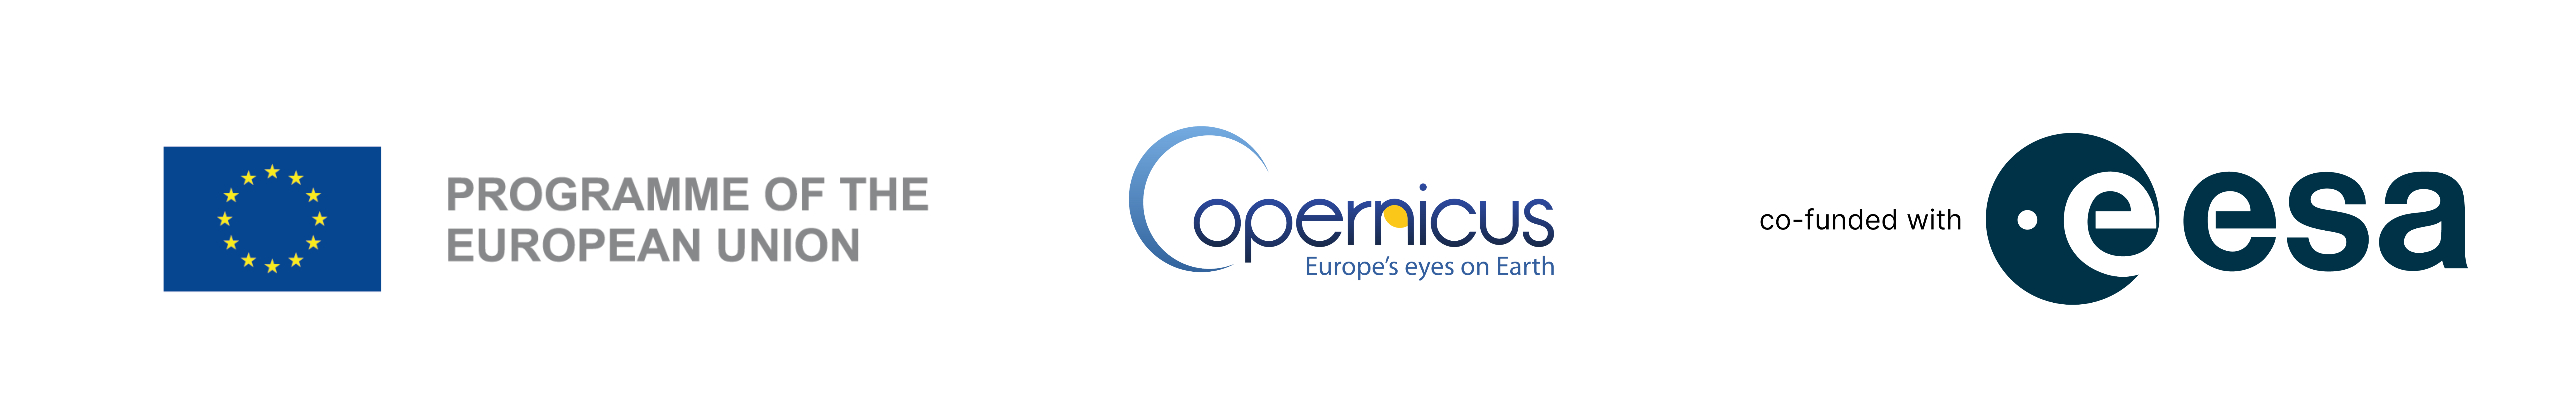